## ``ML-Regression Model - California Housing``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# California Housing dataset
df_cali_house = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-DL/data/CaliforniaHousing/CaliforniaHousing-Dataset.csv', usecols = lambda column: column != 'Unnamed: 0')
df_cali_house.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Features type
df_cali_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# Features description
df_cali_house.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### ``Visualization``

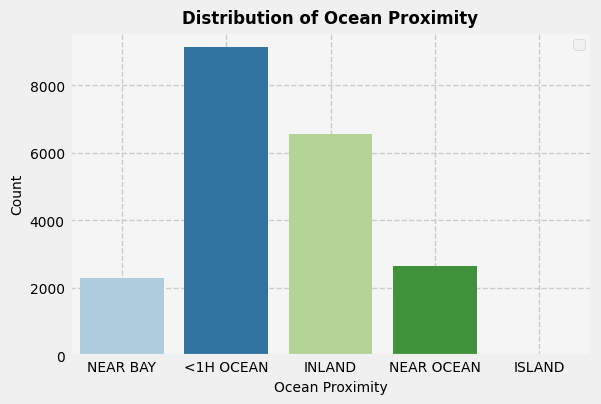

In [5]:
# Visualization - Distribution of Ocean Proximity
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.countplot(data = df_cali_house, x = 'ocean_proximity', palette = 'Paired')
plt.grid(linestyle = '--')
plt.title('Distribution of Ocean Proximity', fontsize = 12, fontweight = 'bold')
plt.ylabel('Count', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Ocean Proximity', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

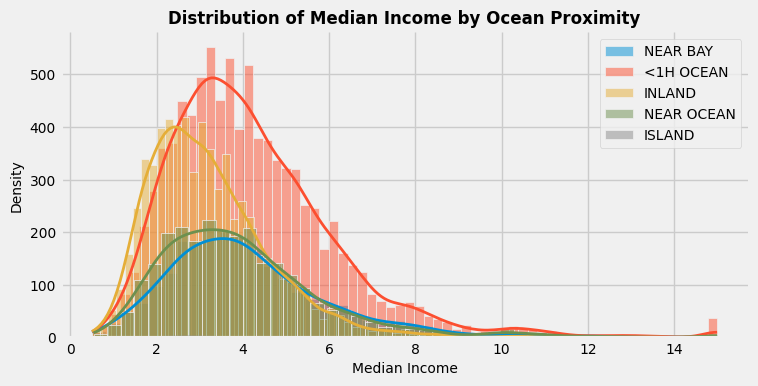

In [6]:
# Visualization - Distribution of Median Income by Ocean Proximity
fig = sns.FacetGrid(df_cali_house, hue = 'ocean_proximity', height = 4, aspect = 2)
fig.map(sns.histplot, 'median_income', kde = True, line_kws = {'lw': 2})
fig.set_axis_labels('Median Income', 'Density', fontsize = 10) 
plt.title('Distribution of Median Income by Ocean Proximity', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

#### ``Data Pre-Processing``

In [7]:
# NA-values
df_cali_house['total_bedrooms'].fillna(df_cali_house['total_bedrooms'].median(), inplace = True)
for col in df_cali_house.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_cali_house[col].isnull().sum()))

longitude column missing values: 0
latitude column missing values: 0
housing_median_age column missing values: 0
total_rooms column missing values: 0
total_bedrooms column missing values: 0
population column missing values: 0
households column missing values: 0
median_income column missing values: 0
median_house_value column missing values: 0
ocean_proximity column missing values: 0


In [8]:
# Feature Selection + Target
X = df_cali_house.drop(['median_house_value'], axis = 1)
Y = df_cali_house['median_house_value']
print(X.shape)
print(Y.shape)

(20640, 9)
(20640,)


In [9]:
# Categorical features
encoder = LabelEncoder()
X['ocean_proximity'] = encoder.fit_transform(X['ocean_proximity'])
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3


In [10]:
# Numerical features
sc = StandardScaler()

numerical_variables = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for col in numerical_variables:
    X[[col]] = sc.fit_transform(X[[col]])
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,3
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,3
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,3
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,3
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,3


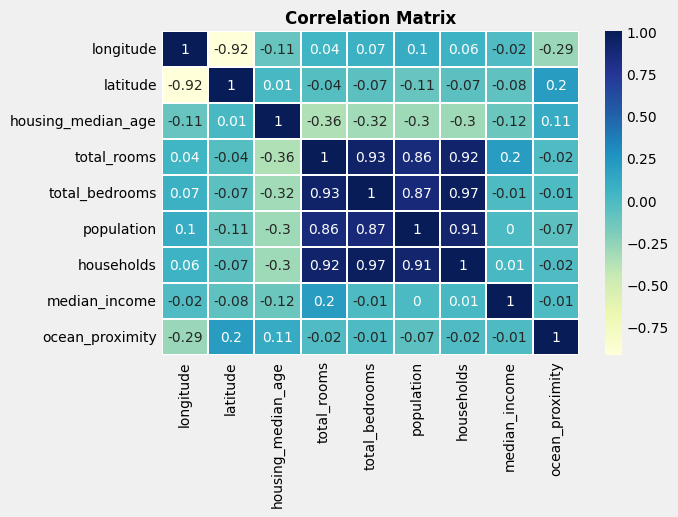

In [11]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [12]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(15480, 9)
(15480,)
(5160, 9)
(5160,)


#### ``Modelling``

In [13]:
# 1. K-Nearest Neighbors (KNN) model

# Model
model_knn = KNeighborsRegressor(n_neighbors = 5)

# Training
model_knn.fit(X_train, Y_train)

# Predict
y_pred_knn = model_knn.predict(X_test)

# Evaluation
mae_knn = mean_absolute_error(Y_test, y_pred_knn)
mse_knn = mean_squared_error(Y_test, y_pred_knn)
print(f'K-Nearest Neighbors (KNN) model \n -> MAE = {mae_knn:.4f} \n -> MSE = {mse_knn:.4f}')

K-Nearest Neighbors (KNN) model 
 -> MAE = 41272.1333 
 -> MSE = 3857543503.2393


In [14]:
# 2. Decision Tree Regressor (DT) model

# Model
model_dt = DecisionTreeRegressor(random_state = 42)

# Training
model_dt.fit(X_train, Y_train)

# Predict
y_pred_dt = model_dt.predict(X_test)

# Evaluation
mae_dt = mean_absolute_error(Y_test, y_pred_dt)
mse_dt = mean_squared_error(Y_test, y_pred_dt)
print(f'Decision Tree Regressor (DT) model \n -> MAE = {mae_dt:.4f} \n -> MSE = {mse_dt:.4f}')

Decision Tree Regressor (DT) model 
 -> MAE = 42977.2667 
 -> MSE = 4752330353.0612


In [15]:
# 3. Support Vector Regressor (SVR) model

# Model
model_svr = SVR(kernel = 'rbf', C = 1e3, gamma = 0.1)

# Training
model_svr.fit(X_train, Y_train)

# Predict
y_pred_svr = model_svr.predict(X_test)

# Evaluation
mae_svr = mean_absolute_error(Y_test, y_pred_svr)
mse_svr = mean_squared_error(Y_test, y_pred_svr)
print(f'Support Vector Regressor (SVR) model \n -> MAE = {mae_svr:.4f} \n -> MSE = {mse_svr:.4f}')

Support Vector Regressor (SVR) model 
 -> MAE = 49213.6412 
 -> MSE = 5179063039.4412


In [16]:
# 4. Linear Regression (LR) model

# Model
model_lr = LinearRegression()

# Training
model_lr.fit(X_train, Y_train)

# Predict
y_pred_lr = model_lr.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(Y_test, y_pred_lr)
mse_lr = mean_squared_error(Y_test, y_pred_lr)
print(f'Linear Regression (LR) model \n -> MAE = {mae_lr:.4f} \n -> MSE = {mse_lr:.4f}')

Linear Regression (LR) model 
 -> MAE = 51184.5382 
 -> MSE = 4968284748.1179


In [17]:
# 5. Random Forest Regressor (RF) model

# Model
model_rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

# Training
model_rf.fit(X_train, Y_train)

# Predict
y_pred_dt = model_rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(Y_test, y_pred_dt)
mse_rf = mean_squared_error(Y_test, y_pred_dt)
print(f'Random Forest Regressor (RF) model \n -> MAE = {mae_rf:.4f} \n -> MSE = {mse_rf:.4f}')

Random Forest Regressor (RF) model 
 -> MAE = 32171.3840 
 -> MSE = 2461189355.1722


Which is the **``best performing model``**?  

- **Linear Regression (LR) model**: achieved $MAE = 51,184$ and $MSE = 4.97B$. While simple, it performs reasonably well, suggesting a linear relationship between the features and target variable, though it's outperformed by more complex models.

- **Random Forest Regressor (RF) model**: achieved $MAE = 32,151$ and $MSE = 2.46B$, delivering the best performance among the models tested. It effectively captures non-linear relationships, offering a good balance between complexity and predictive accuracy.

- **Decision Tree Regressor (DT) model**: had $MAE = 42,977$ and $MSE = 4.77B$, showing significant overfitting and poor precision.

- **Support Vector Regressor (SVR) model**: resulted in $MAE = 87,552$ and $MSE = 13.72B$, performing suboptimally due to sensitivity to hyperparameters and scaling issues.

- **K-Nearest Neighbors (KNN) model**: performed the worst, with $MAE = 77,290$ and $MSE = 9.98B$. It struggles with high-dimensional and evolving data, leading to poor generalization.

The **``Random Forest Regressor (RF) model``** is the **best performing model**, providing the lowest error metrics and effectively capturing complex relationships in the data, making it the most suitable choice for this task.